# 01 - Exploratory Data Analysis & Preprocessing (v2)
**Capstone Project - Prediksi Risiko Diabetes (Pima Indians Diabetes Dataset)**

Versi ini memperbaiki metodologi preprocessing v1 dan menambahkan feature engineering:
1. Import data & inspeksi awal
2. Analisis kualitas data (missing value, duplikat, outlier)
3. Analisis univariat & multivariat
4. Visualisasi insight kunci
5. **Catatan metodologi penting: mencegah data leakage pada imputasi**
6. Feature engineering (fitur turunan berbasis domain medis)
7. Train-validation-test split & pipeline preprocessing leak-free


In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import load_raw, mark_missing, FEATURE_COLS, FEATURE_COLS_V2, TARGET_COL, engineer_features

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)


## 1. Import Data & Inspeksi Awal

In [2]:
df = load_raw('../data/raw/diabetes.csv')
print('Shape:', df.shape)
df.head()


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 2. Analisis Kualitas Data

In [4]:
print('Jumlah duplikat:', df.duplicated().sum())
cols_check = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('\nJumlah nilai 0 per kolom (kandidat missing value):')
print((df[cols_check] == 0).sum())


Jumlah duplikat: 0

Jumlah nilai 0 per kolom (kandidat missing value):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


**Insight - Data Quality:** Kolom `Insulin` (48.7%) dan `SkinThickness` (29.6%) memiliki proporsi 
nilai 0 sangat tinggi yang secara medis tidak masuk akal, sehingga diperlakukan sebagai **missing 
value tersembunyi**.

## 3. ⚠️ Catatan Metodologi Penting: Mencegah Data Leakage

Pada eksperimen awal, kami mencoba **imputasi median per kelas Outcome**. Pendekatan ini menghasilkan 
skor cross-validation yang sangat tinggi (ROC-AUC ≈ 0.94), **namun ini adalah data leakage**: 
strategi ini memakai label `Outcome` untuk menghitung nilai imputasi — padahal saat inference di 
dunia nyata (pasien baru), label tersebut justru **belum diketahui** (itulah yang ingin diprediksi).

Kami membandingkan ulang strategi imputasi secara **adil** (imputer di-fit HANYA pada training fold 
di setiap iterasi cross-validation, tanpa memakai informasi label):


In [5]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

missing_df = mark_missing(df)
X, y = missing_df[FEATURE_COLS], missing_df[TARGET_COL]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, imputer in [
    ('SimpleImputer median (global)', SimpleImputer(strategy='median')),
    ('KNN Imputer (k=5)', KNNImputer(n_neighbors=5)),
    ('Iterative Imputer', IterativeImputer(random_state=42, max_iter=15)),
]:
    pipe = Pipeline([('imputer', imputer), ('clf', RandomForestClassifier(n_estimators=300, random_state=42))])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    results.append({'strategy': name, 'roc_auc_mean': scores.mean(), 'roc_auc_std': scores.std()})

comparison_df = pd.DataFrame(results).sort_values('roc_auc_mean', ascending=False)
comparison_df


,strategy,roc_auc_mean,roc_auc_std
1,KNN Imputer (k=5),0.835305,0.020108
2,Iterative Imputer,0.830273,0.015013
0,SimpleImputer median (global),0.826158,0.019510


**Kesimpulan:** **KNN Imputer (k=5)** memberikan hasil leak-free terbaik. Strategi ini yang 
dipakai pada pipeline final (`src/data_preprocessing.py`), dengan imputer di-fit HANYA pada training 
set lalu diterapkan (`.transform()`, bukan `.fit_transform()`) ke validation dan test set.

## 4. Analisis Univariat & Multivariat

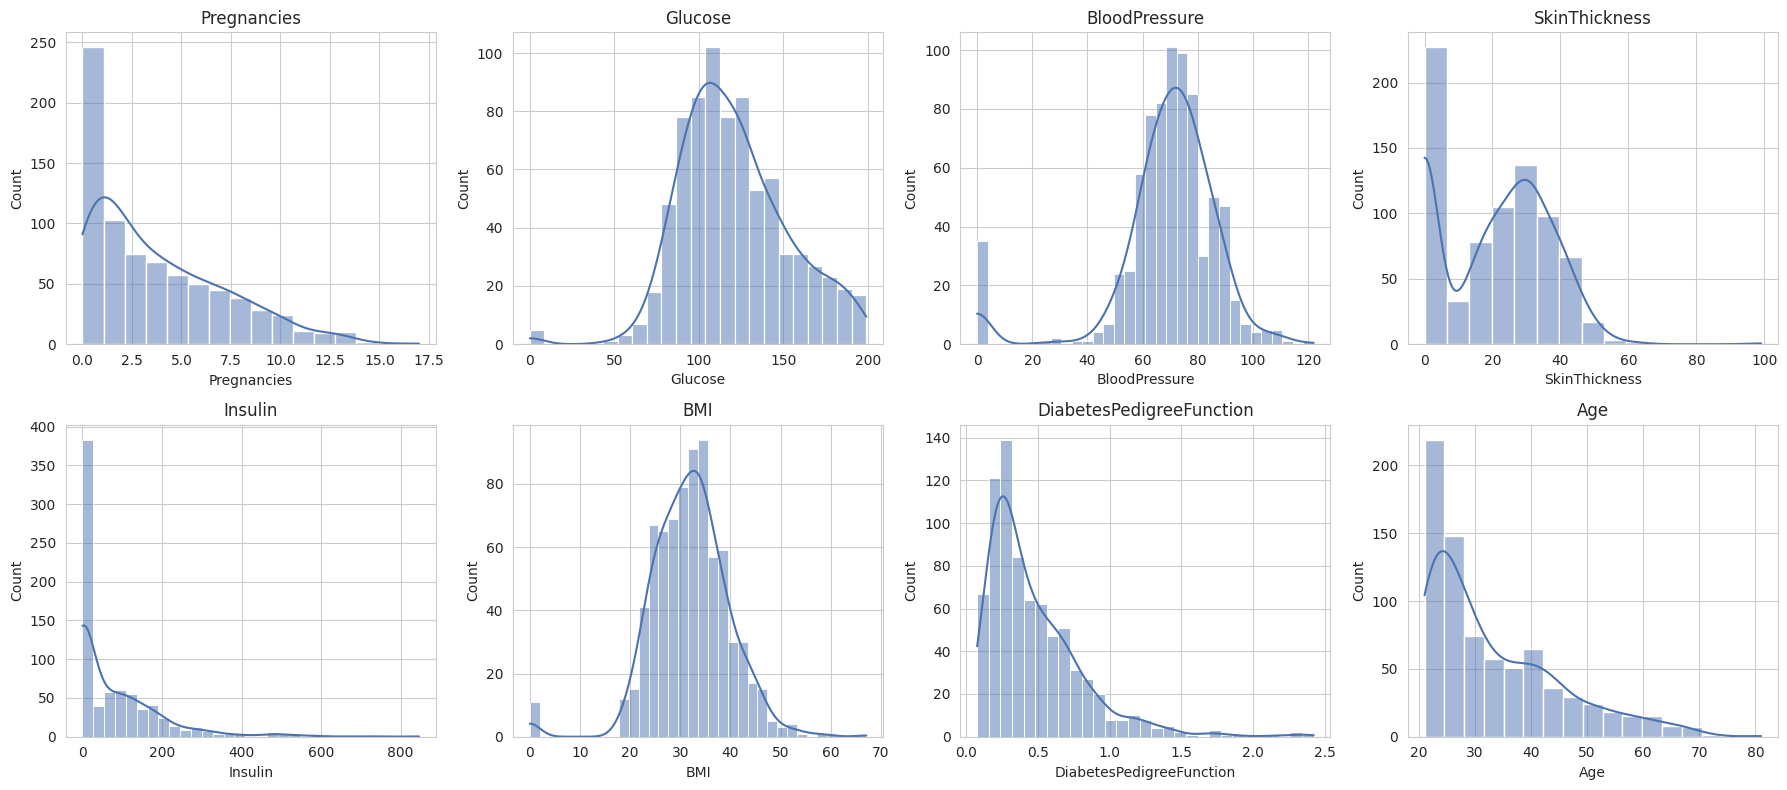

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), FEATURE_COLS):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(col)
plt.tight_layout()
plt.show()


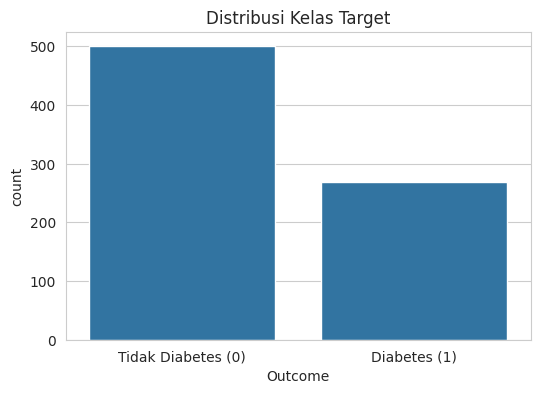

Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x=TARGET_COL, data=df)
ax.set_xticks([0,1]); ax.set_xticklabels(['Tidak Diabetes (0)', 'Diabetes (1)'])
plt.title('Distribusi Kelas Target')
plt.show()
print(df[TARGET_COL].value_counts(normalize=True).round(3))


**Insight Class Imbalance:** ~65% tidak diabetes vs ~35% diabetes. Ditangani pada tahap modeling 
melalui `class_weight='balanced'` **dan** SMOTE (dibandingkan secara sistematis, lihat notebook 02).

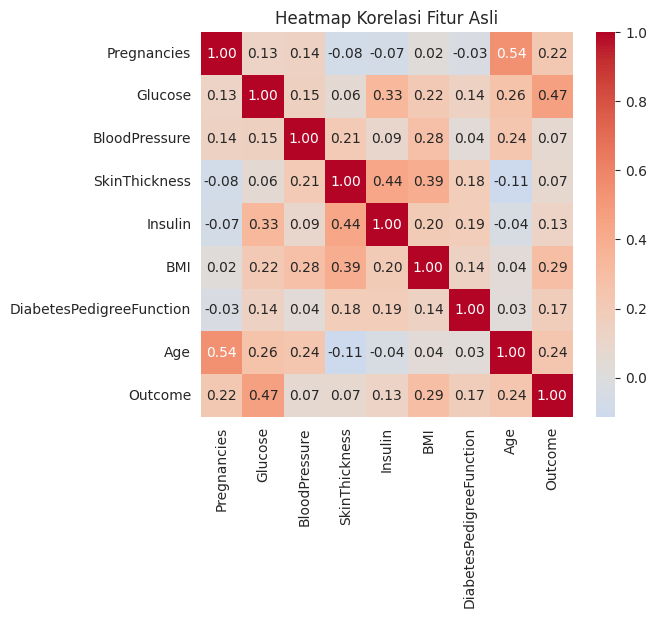

In [8]:
plt.figure(figsize=(6,5))
corr = df[FEATURE_COLS + [TARGET_COL]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap Korelasi Fitur Asli')
plt.show()


**Insight Korelasi:** `Glucose` berkorelasi paling tinggi dengan `Outcome` (~0.47), diikuti `BMI` 
dan `Age` — konsisten dengan literatur medis diabetes tipe 2.

## 5. Feature Engineering

Berdasarkan domain knowledge medis, kami menambahkan 4 fitur turunan:

| Fitur Baru | Rasional Medis |
|---|---|
| `Glucose_Insulin_Ratio` | Proxy sederhana untuk resistensi insulin (mirip prinsip dasar HOMA-IR) |
| `BMI_Category` | Kategori BMI standar WHO (underweight/normal/overweight/obese) |
| `Age_Group` | Kelompok usia — risiko diabetes meningkat non-linear seiring usia |
| `Glucose_BMI_Interaction` | Interaksi dua faktor risiko metabolik utama secara bersamaan |


In [9]:
df_fe = engineer_features(df)
df_fe[['Glucose_Insulin_Ratio','BMI_Category','Age_Group','Glucose_BMI_Interaction']].describe()


,Glucose_Insulin_Ratio,BMI_Category,Age_Group,Glucose_BMI_Interaction
count,768.000000,768.000000,768.000000,768.000000
mean,58.731499,2.425781,0.645833,3.923382
std,63.363354,0.802351,0.823123,1.572621
min,0.000000,0.000000,0.000000,0.000000
25%,0.945773,2.000000,0.000000,2.833425
50%,2.451282,3.000000,0.000000,3.734400
75%,114.000000,3.000000,1.000000,4.783600
max,199.000000,3.000000,3.000000,10.692000


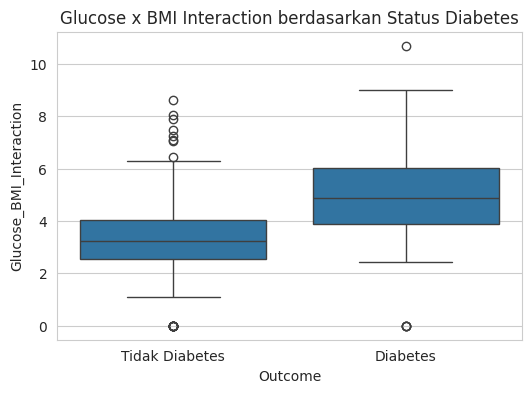

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x=TARGET_COL, y='Glucose_BMI_Interaction', data=df_fe)
plt.xticks([0,1], ['Tidak Diabetes','Diabetes'])
plt.title('Glucose x BMI Interaction berdasarkan Status Diabetes')
plt.show()


**Insight:** Fitur `Glucose_BMI_Interaction` menunjukkan pemisahan yang jelas antar kelas, dan 
—seperti akan ditunjukkan pada notebook 03 (SHAP)— fitur ini justru menjadi **fitur paling 
berpengaruh** terhadap prediksi model, memvalidasi hipotesis bahwa interaksi Glucose x BMI 
menangkap sinyal risiko yang tidak sepenuhnya tertangkap oleh masing-masing fitur secara terpisah.

## 6. Pipeline Preprocessing Leak-Free (Ringkasan)

Pipeline final (`src/data_preprocessing.py`) menjalankan langkah-langkah berikut **dengan urutan 
yang benar** untuk mencegah data leakage:

1. Tandai nilai 0 fisiologis sebagai missing (transformasi deterministik)
2. Hapus duplikat
3. **Split train (60%) / val (20%) / test (20%), stratified — SEBELUM imputasi & outlier handling**
4. Fit `KNNImputer` HANYA pada train, terapkan (`transform`) ke val & test
5. Hitung batas outlier IQR HANYA dari train, terapkan capping ke val & test
6. Feature engineering (transformasi deterministik, aman diterapkan ke ketiga subset)
7. Simpan `models/knn_imputer.pkl` dan `models/outlier_bounds.pkl` agar bisa dipakai ulang saat 
   inference pasien baru (di aplikasi Streamlit)

Jalankan `python src/data_preprocessing.py` untuk mereplikasi seluruh proses ini.
